# PA4 : Hugging Face Transformers

In [1]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.3/93.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.0/139.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 20.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install bert-extractive-summarizer
!pip install torch torchvision torchaudio  # Ensure PyTorch is installed
!pip install transformers
!pip install sentencepiece

In [5]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
import spacy
from collections import Counter
from transformers import pipeline
import random
from summarizer import Summarizer
from nltk.tokenize import sent_tokenize
import evaluate
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
from kaggle_secrets import UserSecretsClient
import wandb
import torch
rom wordcloud import WordCloud
from nltk.tokenize import sent_tokenize

In [7]:
dataset = load_dataset("samsum")

README.md:   0%|          | 0.00/7.04k [00:00<?, ?B/s]

samsum.py:   0%|          | 0.00/3.36k [00:00<?, ?B/s]

The repository for samsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/samsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


corpus.7z:   0%|          | 0.00/2.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

In [8]:
train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

In [9]:
print(train_data[0])

{'id': '13818513', 'dialogue': "Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)", 'summary': 'Amanda baked cookies and will bring Jerry some tomorrow.'}


In [10]:
len(train_data)

14732

## 2. Exploratory Data Analysis

In [ ]:
df_train=pd.DataFrame(train_data)
df_train["dialogue_length"] = df_train["dialogue"].apply(lambda x: len(x.split()))
df_train["summary_length"] = df_train["summary"].apply(lambda x: len(x.split()))
df_train[["dialogue_length", "summary_length"]].describe()

,dialogue_length,summary_length
count,14732.000000,14732.000000
mean,93.786383,20.317472
std,74.033457,11.153815
min,0.000000,1.000000
25%,39.000000,12.000000
50%,73.000000,18.000000
75%,128.000000,27.000000
max,803.000000,64.000000


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


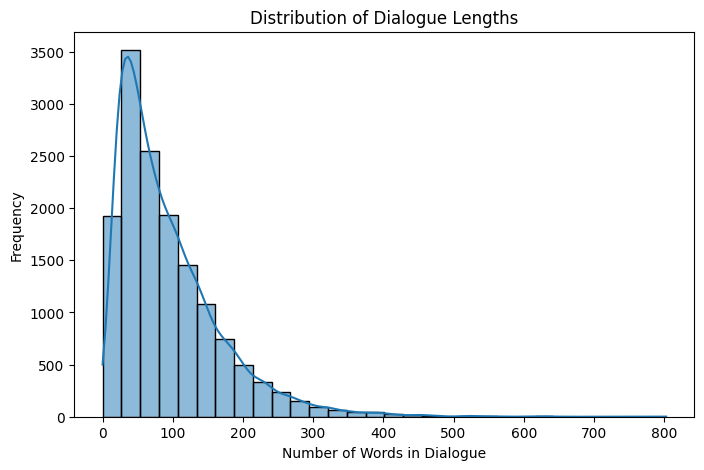

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train["dialogue_length"], bins=30, kde=True)
plt.xlabel("Number of Words in Dialogue")
plt.ylabel("Frequency")
plt.title("Distribution of Dialogue Lengths")
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


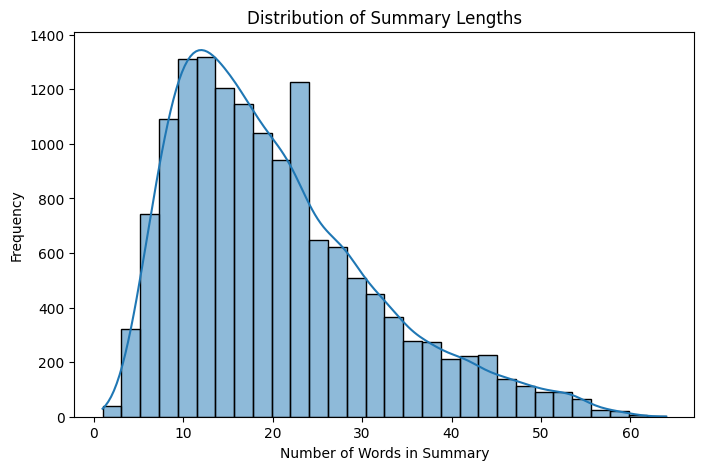

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train["summary_length"], bins=30, kde=True)
plt.xlabel("Number of Words in Summary")
plt.ylabel("Frequency")
plt.title("Distribution of Summary Lengths")
plt.show()

In [14]:
nltk.download('punkt_tab')

# Assuming df_train is your dataframe containing the "dialogue" column
all_words = [word.lower() for text in df_train["dialogue"] for word in word_tokenize(text)]

# Calculate word frequency
word_freq = Counter(all_words)

# Print the top 20 most common words
print(word_freq.most_common(20))


[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[(':', 177291), ('i', 60559), (',', 53084), ('.', 47757), ('?', 43003), ('you', 42846), ('!', 33391), ('the', 31559), ('to', 29199), ('it', 27988), ('a', 22262), ('and', 17728), ("'s", 16986), ('that', 14141), ('do', 13284), ("n't", 13029), ('for', 11982), ('is', 11718), ('in', 11562), ('have', 11396)]


In [15]:
unique_summaries = df_train["summary"].nunique()
total_summaries = len(df_train)
print(f"Unique Summaries: {unique_summaries}/{total_summaries} ({(unique_summaries/total_summaries)*100:.2f}%)")

Unique Summaries: 14730/14732 (99.99%)


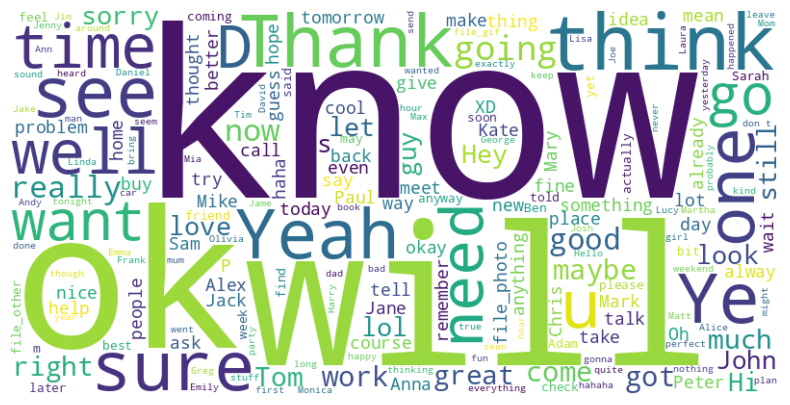

In [ ]:
text = " ".join(df_train["dialogue"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Sentiment Analysis
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()
# Example sentiment score
print(sia.polarity_scores(dataset["train"][0]["dialogue"]))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
{'neg': 0.0, 'neu': 0.66, 'pos': 0.34, 'compound': 0.636}


The text is mostly neutral but leans positive, suggesting it contains some optimistic or encouraging language without strong emotional extremes.

In [18]:
pip install --upgrade spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.2/29.2 MB 66.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 74.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 92.5 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: blis
    Found existing installation: blis 0.7.11
    Uninstalling blis-0.7.11:
      Successfully uninstalled blis-0.7.11
  Attempting uninstall: thinc
    Found existing installation: thinc 8.2.5
    Uninstalling thinc-8.2.5:
      Successfully uninstalled thinc-8.2.5
  Attempting uninstall: spacy
    Found existing installation: spacy 3.7.5
    Uninstalling spacy-3.7.5:
      Successfully uninstalled spacy-3.7.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
en-core-web-sm 3.7.1 requires spacy<3.8.0,>=3.7.2, but you have spacy 3.8.4 which is incompatible.
Note: you may need to

In [ ]:
# NER analysis
nlp = spacy.load("en_core_web_sm")

# Initialize a counter to store entity frequency
entity_counter = Counter()

# Assuming your train dataframe is called 'train_df' and has a column "dialogue"
for index, row in df_train.iterrows():
    sample_text = row["dialogue"]  # Get the dialogue text from the DataFrame row
    doc = nlp(sample_text)  # Process the dialogue

    # Extract and update the counter with entity text
    for ent in doc.ents:
        entity_counter[ent.text] += 1

# Get the most common entities (top N, for example, top 5)
most_common_entities = entity_counter.most_common(5)

# Print the most popular entities
print("Most Popular Entities:")
for entity, count in most_common_entities:
    print(f"{entity}: {count}")

/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


Most Popular Entities:
Tom: 2121
John: 1777
Kate: 1568
today: 1475
tomorrow: 1472


In [20]:
# Get the most common entities (top N, for example, top 10)
most_common_entities = entity_counter.most_common(10)

# Print the most popular entities
print("Most Popular Entities:")
for entity, count in most_common_entities:
    print(f"{entity}: {count}")

Most Popular Entities:
Tom: 2121
John: 1777
Kate: 1568
today: 1475
tomorrow: 1472
Peter: 1426
Mary: 1286
Mike: 1284
Anna: 1240
Mark: 1110


## 3. Inference with pre-trained models

### BART

In [21]:
df_test=pd.DataFrame(test_data)
# Randomly select a few dialogues (e.g., 3 random dialogues)
random_dialogues = df_test["dialogue"].sample(n=3, random_state=42).tolist()

# Initialize summarization pipeline for each model
summarizer_bart = pipeline("summarization", model="facebook/bart-large-cnn")
summaries_bart=[]

# Summarize using the different models
for dialogue in random_dialogues:
    input_length = len(dialogue.split())  # Count words in the input dialogue
    max_length = min(input_length // 2, 150)  # Set max_length to half of input length, max 150
    summaries_bart.append(summarizer_bart(dialogue, max_length=max_length)[0]['summary_text'])

# Print out the results
for i, dialogue in enumerate(random_dialogues):
    print(f"Dialogue {i+1}:")
    print(f"Original: {dialogue}")
    print(f"BART Summary: {summaries_bart[i]}")
    print("-" * 50)


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Your min_length=56 must be inferior than your max_length=53.
/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1427: UserWarning: Unfeasible length constraints: `min_length` (56) is larger than the maximum possible length (53). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(
Your min_length=56 must be inferior than your max_length=36.
/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1427: UserWarning: Unfeasible length constraints: `min_length` (56) is larger than the maximum possible length (36). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(
Your min_length=56 must be inferior than your max_length=34.
/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1427: UserWarning: Unfeasible length constraints: `

Dialogue 1:
Original: Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
BART Summary: Olafur and Zoe discuss their plans for New Year's Eve. They plan to go to a 'classy' party in Soho. They also want to see if the club is 'amazing' Olafur asks if the party will
--------------------------------------------------
Dialogue 2:
Original: Javier: Hey do you know any tattoo parlors over here with English speaking employees?
Judie: Oh

### T5

In [22]:
summarizer_t5 = pipeline("summarization", model="t5-large")
summaries_t5=[]

# Summarize using the different models
for dialogue in random_dialogues:
    input_length = len(dialogue.split())  # Count words in the input dialogue
    max_length = min(input_length // 2, 150)  # Set max_length to half of input length, max 150
    summaries_t5.append(summarizer_t5(dialogue, max_length=max_length)[0]['summary_text'])

# Print out the results
for i, dialogue in enumerate(random_dialogues):
    print(f"Dialogue {i+1}:")
    print(f"Original: {dialogue}")
    print(f"T5 Summary: {summaries_t5[i]}")
    print("-" * 50)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0


Dialogue 1:
Original: Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
T5 Summary: Nathalie: i was thinking about something classy, like opera or sth like that Zoe: how much does it cost? olafur: opera is not for me .
--------------------------------------------------
Dialogue 2:
Original: Javier: Hey do you know any tattoo parlors over here with English speaking employees?
Judie: Oh there's Warsaw ink
Javier: the name sounds 

### PEGASUS

In [23]:
summarizer_pegasus = pipeline("summarization", model="google/pegasus-large")
summaries_pegasus=[]

# Summarize using the different models
for dialogue in random_dialogues:
    input_length = len(dialogue.split())  # Count words in the input dialogue
    max_length = min(input_length // 2, 150)  # Set max_length to half of input length, max 150
    summaries_pegasus.append(summarizer_pegasus(dialogue, max_length=max_length)[0]['summary_text'])

for i, dialogue in enumerate(random_dialogues):
    print(f"Dialogue {i+1}:")
    print(f"Original: {dialogue}")
    print(f"PEGASUS Summary: {summaries_pegasus[i]}")
    print("-" * 50)


config.json:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-large and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cuda:0


Dialogue 1:
Original: Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
PEGASUS Summary: Nathalie: it's 100$ Olafur: I was thinking about partying somewhere Nathalie: partying sounds fun, as long as it will be classy Zoe: file_link> Zoe: Breakfast at Tiffany's party sounds classy
--------------------------------------------------
Dialogue 2:
Original: Javier: Hey do you know any tattoo parlors over here with English speaking em

### BERTSUM

In [24]:
summaries_bertsum = []
summarizer_bertsum = Summarizer()

# Summarize using BERTSUM
for dialogue in random_dialogues:
    input_length = len(dialogue.split())  # Count words in the input dialogue
    max_ratio = 0.3  # Summarize to 30% of the original text length
    summary = summarizer_bertsum(dialogue, ratio=max_ratio)
    summaries_bertsum.append(summary)

# Print the results
for i, dialogue in enumerate(random_dialogues):
    print(f"Dialogue {i+1}:")
    print(f"Original: {dialogue}")
    print(f"BERTSUM Summary: {summaries_bertsum[i]}")
    print("-" * 50)


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Dialogue 1:
Original: Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
BERTSUM Summary: Olafur: are we doing anything for New Year's Eve? Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
--------------------------------------------------
Dialogue 2:
Original: Javier: Hey do you know any tattoo parlors over here with Eng

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## 4. Define a Baseline

In [ ]:
# Generate Lead-3 baseline summaries
lead3_summaries = []
for dialogue in random_dialogues:
    sentences = sent_tokenize(dialogue)  # Split dialogue into sentences
    lead3_summary = " ".join(sentences[:3])  # Take the first 3 sentences
    lead3_summaries.append(lead3_summary)

# Print some examples
for i, dialogue in enumerate(random_dialogues):
    print(f"Dialogue {i+1}:")
    print(f"Original: {dialogue}")
    print(f"Lead-3 Summary: {lead3_summaries[i]}")
    print("-" * 50)

Dialogue 1:
Original: Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure
Lead-3 Summary: Olafur: are we doing anything for New Year's Eve? Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost? Olafur: opera is not for me
Nathalie: so what do you propose?
--------------------------------------------------
Dialogue 2:
Original: Javier: Hey do you know any tattoo parlors over here 

In [26]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=ac4412104dcbc65e5cc9415cfccec5f9728954602eedbbc70c7ee50086726074
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [27]:
rouge = evaluate.load("rouge")

# Compute ROUGE scores for Lead-3 baseline
lead3_rouge_scores = rouge.compute(predictions=lead3_summaries, references=random_dialogues)

# Compute ROUGE scores for pre-trained models
bart_rouge_scores = rouge.compute(predictions=summaries_bart, references=random_dialogues)
t5_rouge_scores = rouge.compute(predictions=summaries_t5, references=random_dialogues)
pegasus_rouge_scores = rouge.compute(predictions=summaries_pegasus, references=random_dialogues)

# Print results
print("ROUGE Scores for Lead-3 Baseline:", lead3_rouge_scores)
print("ROUGE Scores for BART:", bart_rouge_scores)
print("ROUGE Scores for T5:", t5_rouge_scores)
print("ROUGE Scores for PEGASUS:", pegasus_rouge_scores)


ROUGE Scores for Lead-3 Baseline: {'rouge1': 0.6336517512988101, 'rouge2': 0.6276149342547269, 'rougeL': 0.6336517512988101, 'rougeLsum': 0.6336517512988101}
ROUGE Scores for BART: {'rouge1': 0.39101425902999504, 'rouge2': 0.2573211294208014, 'rougeL': 0.33180616189917683, 'rougeLsum': 0.373595002280576}
ROUGE Scores for T5: {'rouge1': 0.4304264310411064, 'rouge2': 0.3765830346475508, 'rougeL': 0.39533871174286084, 'rougeLsum': 0.4304264310411064}
ROUGE Scores for PEGASUS: {'rouge1': 0.43041530492007385, 'rouge2': 0.41915381551377506, 'rougeL': 0.43041530492007385, 'rougeLsum': 0.43041530492007385}


- The Lead-3 baseline surprisingly performs the best, likely because dialogues have a natural structure where important information is front-loaded.
- PEGASUS and T5 generate the best summaries among the models, with PEGASUS being slightly better at capturing fine-grained details.
- BART underperforms compared to the other models, meaning it might not be the best choice for summarizing this type of dialogue dataset.

## 5. Fine Tuning

In [28]:
tokenizer = T5Tokenizer.from_pretrained("t5-small")

def preprocess_function(example):
    inputs = ["summarize: " + dialogue for dialogue in example["dialogue"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length", return_tensors="pt")

    labels = tokenizer(example["summary"], max_length=150, truncation=True, padding="max_length", return_tensors="pt").input_ids
    model_inputs["labels"] = labels
    return model_inputs

tokenized_datasets = dataset.map(preprocess_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

In [31]:
# Retrieve Wandb API key from Kaggle Secrets
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("Wandb key")

# Log into Wandb
wandb.login(key=wandb_key)

# Define train and validation datasets
train_dataset = tokenized_datasets["train"]
val_dataset = tokenized_datasets["test"]

# Load the model
model = T5ForConditionalGeneration.from_pretrained("t5-small")

# Define training arguments with Wandb integration
training_args = TrainingArguments(
    output_dir="./t5_samsum",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="wandb",  # Enable Wandb logging
    run_name="t5_samsum_finetuning",  # Name of the Wandb run
    fp16=False
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Start training
trainer.train()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.416300,0.343830
2,0.346100,0.336316
3,0.363400,0.332947


/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=5526, training_loss=0.4074170598291721, metrics={'train_runtime': 1599.9255, 'train_samples_per_second': 27.624, 'train_steps_per_second': 3.454, 'total_flos': 5981566257856512.0, 'train_loss': 0.4074170598291721, 'epoch': 3.0})

In [32]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    return rouge.compute(predictions=decoded_preds, references=decoded_labels)

trainer.evaluate()

/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.33294686675071716,
 'eval_runtime': 11.092,
 'eval_samples_per_second': 73.837,
 'eval_steps_per_second': 9.286,
 'epoch': 3.0}

In [33]:
model.save_pretrained("./t5_samsum_finetuned")
tokenizer.save_pretrained("./t5_samsum_finetuned")

('./t5_samsum_finetuned/tokenizer_config.json',
 './t5_samsum_finetuned/special_tokens_map.json',
 './t5_samsum_finetuned/spiece.model',
 './t5_samsum_finetuned/added_tokens.json')

## 6. Evaluation and Analysis

In [36]:
# Load the fine-tuned model and tokenizer
fine_tuned_model = T5ForConditionalGeneration.from_pretrained("./t5_samsum_finetuned")
fine_tuned_tokenizer = T5Tokenizer.from_pretrained("./t5_samsum_finetuned")

# Load the pre-trained model and tokenizer
pretrained_model = T5ForConditionalGeneration.from_pretrained("t5-small")
pretrained_tokenizer = T5Tokenizer.from_pretrained("t5-small")

# Load the dataset (assuming the dataset is already loaded and tokenized)
dataset = load_dataset("samsum")
tokenized_datasets = dataset.map(preprocess_function, batched=True)

# Initialize the ROUGE metric
rouge = evaluate.load("rouge")

# Define function for generating summaries and computing ROUGE score
def evaluate_model(model, tokenizer, test_dataset):
    model.eval()  # Set model to evaluation mode
    predictions = []
    references = []
    
    # Generate summaries for the test set
    for example in test_dataset:
        input_text = example['dialogue']  # Use 'dialogue' as input for summarization
        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        
        with torch.no_grad():
            summary_ids = model.generate(inputs['input_ids'], num_beams=4, max_length=150, length_penalty=2.0, early_stopping=True)
        
        decoded_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        predictions.append(decoded_summary)
        references.append(example['summary'])  # Assuming 'summary' is the reference
    
    # Compute ROUGE score
    rouge_results = rouge.compute(predictions=predictions, references=references)
    return rouge_results

# Evaluate the fine-tuned model
fine_tuned_rouge = evaluate_model(fine_tuned_model, fine_tuned_tokenizer, tokenized_datasets["test"])
print("ROUGE Scores for Fine-Tuned Model:", fine_tuned_rouge)

# Evaluate the pre-trained model
pre_fine_tuned_rouge = evaluate_model(pretrained_model, pretrained_tokenizer, tokenized_datasets["test"])
print("ROUGE Scores for Pre-fine-tuned Model:", pre_fine_tuned_rouge)


ROUGE Scores for Fine-Tuned Model: {'rouge1': 0.3918914300225773, 'rouge2': 0.16981170686008598, 'rougeL': 0.31330088907537657, 'rougeLsum': 0.3133985599167529}
ROUGE Scores for Pre-fine-tuned Model: {'rouge1': 0.2507653069467785, 'rouge2': 0.06952777188626987, 'rougeL': 0.191584727104259, 'rougeLsum': 0.19155731657174074}


In [37]:
# Compare pre-fine-tuned and fine-tuned model on some test samples
for i in range(5):  # Inspect first 5 samples
    print(f"Dialogue {i+1}:")
    print(f"Original Dialogue: {tokenized_datasets['test'][i]['dialogue']}")
    
    # Pre-fine-tuned summary
    inputs = pretrained_tokenizer(tokenized_datasets['test'][i]['dialogue'], return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        summary_ids = pretrained_model.generate(inputs['input_ids'], num_beams=4, max_length=150, length_penalty=2.0, early_stopping=True)
    pre_fine_tuned_summary = pretrained_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    # Fine-tuned summary
    with torch.no_grad():
        summary_ids = fine_tuned_model.generate(inputs['input_ids'], num_beams=4, max_length=150, length_penalty=2.0, early_stopping=True)
    fine_tuned_summary = fine_tuned_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    print(f"Pre-fine-tuned Summary: {pre_fine_tuned_summary}")
    print(f"Fine-tuned Summary: {fine_tuned_summary}")
    print("-" * 50)

Dialogue 1:
Original Dialogue: Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye
Pre-fine-tuned Summary: : Hey, do you have Betty's number? Amanda: Lemme check Hannah: file_gif> Amanda: Sorry, can't find it. Amanda: Ask Larry Amanda: He called her last time we were at the park together Hannah: file_gif> Amanda: Don't be shy, he's very nice Hannah: If you say so.. Hannah: I'd rather you texte him Amanda: Just text him  Hannah: Urgh.. Alright Hannah: By
Fine-tuned Summary: Hannah has Betty's number. Amanda has Lemme check. Larry called her last time we were at the park together. He called her last time we were at the park together.
----